# Beyond the Thumbs-Up
### What can 8,200 Steam reviews tell us about Wukong's story and world?

**Black Myth: Wukong · Player experience research · September 2026**

A recommendation answers whether someone endorses the whole game. It does not tell us
whether they understood the plot, enjoyed a chapter, or felt immersed in the world.
This project asks: **what useful questions about story and world experience can we
uncover by looking beyond the recommendation?**

**The answer in one minute:**

- A recommending reviewer can enjoy the story without fully understanding it. A
  non-recommending reviewer can praise the storytelling while disliking the gameplay.
- Story, world, and emotion keywords appear in **28.4% of non-recommending reviews**
  versus **17.4% of recommending reviews**. But this comparison reverses within every
  review-length band. Length changes how we should read the numbers.
- The useful outcome is a set of research questions about **chapter context,
  world boundaries, and the relationship between combat and narrative enjoyment**.
  We have evidence that these experiences exist, not a ranking of how common they are.

**For a reader:** follow sections 1–5 for the story. The appendix explains the text model.
Every chart below is saved in the notebook; no installation is needed to read it on GitHub.
Code cells are short and commented so you can also reproduce the calculations.

## 1. Start with two players, not a score

These two selected reviews show why the recommendation alone is an incomplete guide.
The quotes below are the reviewers' words. Our interpretations are separate.

**H16 · Recommended** — [Original review](https://steamcommunity.com/profiles/76561198992854945/recommended/2358720/)

> I didn’t always catch the whole plot, but overall I liked the story.

**Our reading:** the reviewer recommends the game and likes its story, while saying
they did not follow all of the plot.

**H08 · Not recommended** — [Original review](https://steamcommunity.com/profiles/76561198027961613/recommended/2358720/)

> sets up its own original story with outstanding cutscenes

**Our reading:** the reviewer praises the original story and cutscenes but does not
recommend the overall game. Their wider review describes gameplay frustration.

**What this establishes:** recommendation, story enjoyment, and plot comprehension
can be different things. It does not tell us how many players feel each way.

For a game research team, that distinction matters. A single overall rating could
hide a story-comprehension problem, or wrongly suggest that a gameplay complaint is
also a rejection of the story. We need both the overall context and the review text.

## 2. Put those voices in context

We collected reviews directly from the **Steam Reviews API** for application 2358720.
The scope is **English-tagged reviews created September 17, 2025–September 16, 2026 UTC**,
with both recommendation types and all purchase types included. Collection took place
on September 17, 2026.

**One row means one review ID.** It is not one play session or a representative survey
response from every owner of the game. Review text and recommendations are their
state at collection time; older reviews may have been edited.

The saved collection crossed the start-date boundary after 83 pages. Of 8,298 fetched
IDs, 95 were before the window and 3 were at or after its end, leaving 8,200.
[Steam's documentation](https://partner.steamgames.com/doc/store/getreviews) describes
the filters and the playtime-at-review field used here.

**Load the prepared data.** The first code cells set up file paths, check input hashes,
and choose consistent chart colors. The analytical calculations follow immediately.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# This works when opened from either the repository root or the notebooks folder.
ROOT = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
from wukong_research.analysis import load_reviews, match_rates, verify_data

verified_files = verify_data(ROOT)
reviews = load_reviews(ROOT)
evidence = pd.read_csv(
    ROOT / 'data/evidence.csv', dtype={'review_id': str}, keep_default_na=False
)
provenance = json.loads((ROOT / 'data/provenance.json').read_text(encoding='utf-8'))

FIGURES = ROOT / 'reports/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
COLORS = {'Not recommended': '#b9572c', 'Recommended': '#087f83'}
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'savefig.facecolor': 'white',
})
print(
    f'Loaded {len(reviews):,} review records; '
    f'verified {verified_files} prepared input files.'
)

Loaded 8,200 review records; verified 10 prepared input files.


In [2]:
def show_review(reading_id, interpretation):
    """Keep the source quotation and our interpretation visibly separate."""
    row = evidence.set_index('reading_id').loc[reading_id]
    display(Markdown(
        f"**{reading_id} · {row.recommendation}** — [Original review]({row.review_url})\n\n"
        f"> {row.evidence}\n\n**Our reading:** {interpretation}"
    ))

In [3]:
# Check the counting unit and the time window before interpreting any percentages.
start = pd.Timestamp(provenance['window_start_utc'])
end = pd.Timestamp(provenance['window_end_exclusive_utc'])
assert reviews.review_id.is_unique
assert reviews.created_utc.ge(start).all() and reviews.created_utc.lt(end).all()

context = pd.DataFrame({
    'Measure': [
        'Review IDs', 'Recommended', 'Not recommended',
        'Recommendation rate', 'Keyword matches',
    ],
    'Result': [
        f'{len(reviews):,}',
        f'{reviews.recommended.sum():,}',
        f'{(~reviews.recommended).sum():,}',
        f'{reviews.recommended.mean():.1%}',
        f'{reviews.keyword_match.sum():,} ({reviews.keyword_match.mean():.1%})',
    ],
})
display(context.set_index('Measure'))

,Result
Measure,
Review IDs,"8,200"
Recommended,"7,408"
Not recommended,792
Recommendation rate,90.3%
Keyword matches,"1,514 (18.5%)"


**90.3% of these reviews recommend the game.** The close-reading sample intentionally
contains equal numbers of recommending and non-recommending reviews, so it must not
be used to estimate that overall split.

Before collecting a year of data, we used a 90-day pilot: 2,286 reviews, a 50-review
discovery reading, and a separate 40-review assistant check of keyword retrieval.
The pilot helped define the questions. This notebook reports the expanded collection,
plus 24 additional close readings outside that pilot.

The original audit found **34 blank texts, 682 edited reviews, and 1,579 excess copies
of normalized text across distinct IDs**. We keep distinct IDs in descriptive counts.
The English tag is imperfect: one close-reading example is mostly Thai and is marked
uncertain. None of this is evidence about all Wukong players or all languages.

## 3. An apparent pattern changes when we account for length

To find reviews worth reading, we used three small keyword lists:

| Group | Examples | What can go wrong? |
|---|---|---|
| Story | story, plot, lore, narrative, cutscene, ending, character | “Character” may refer to gameplay mechanics. |
| World | world, atmosphere, immersive, immersion | “World 1” can just mean a location. |
| Emotion | emotional, moving, crying, goosebumps, nostalgia | “Moving” can describe movement rather than emotion. |

A review is a **keyword match** if any list matches. The complete lists and variants
are in [the methodology](../docs/methodology.md#keyword-retrieval).
**A match is neither a complaint nor proof of meaningful story feedback.**

First, compare the two recommendation groups without splitting anything else.

In [4]:
# Each rate uses its own recommendation group's review count as the denominator.
overall = match_rates(reviews, 'recommendation')
display(
    overall.rename(columns={
        'reviews': 'Reviews', 'matches': 'Matches', 'match_rate': 'Match rate',
    }).style.format({'Match rate': '{:.1%}'})
)

,Reviews,Matches,Match rate
recommendation,,,
Not recommended,792,225,28.4%
Recommended,7408,1289,17.4%


At first glance, non-recommending reviews appear more likely to discuss our area of
interest: **28.4% versus 17.4%**. One tempting explanation would be that story and world
concerns are especially associated with dissatisfaction.

But a longer review has more opportunities to include any keyword. Are the two groups
equally long? Here “words” means tokens after removing markup and links and normalizing
whitespace. Unchecked template options are still included in this length measure.

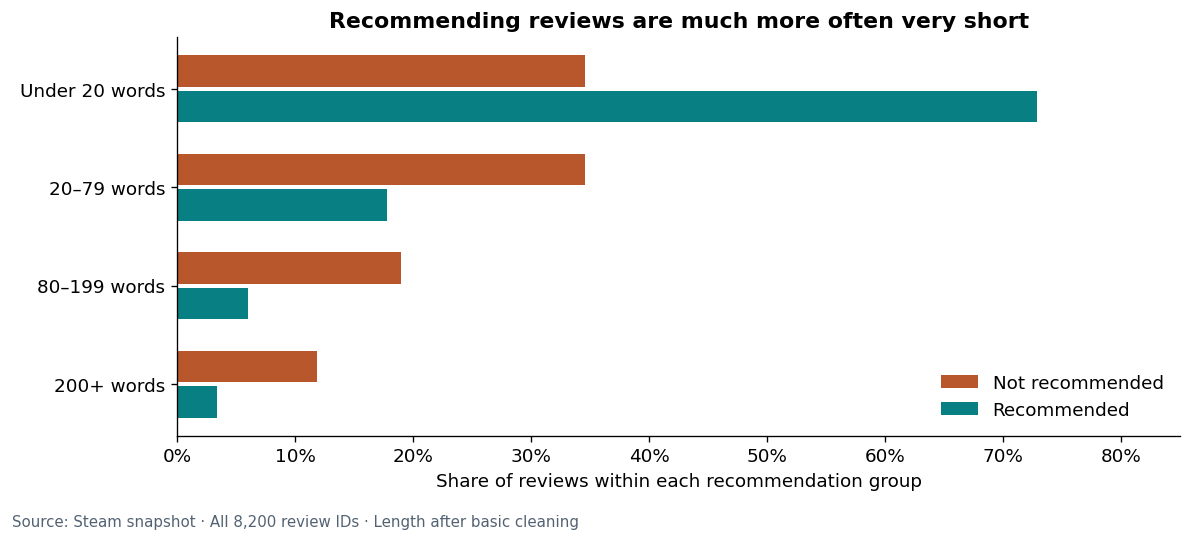

In [5]:
# Compare the mix of review lengths, then use the same bands for the next calculation.
length_counts = pd.crosstab(reviews.length_band, reviews.recommendation)
length_mix = length_counts.div(length_counts.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(10, 4.5))
for offset, group in [(-0.18, 'Not recommended'), (0.18, 'Recommended')]:
    ax.barh(
        np.arange(4) + offset, length_mix[group],
        height=0.32, label=group, color=COLORS[group],
    )
ax.set(
    yticks=np.arange(4), yticklabels=length_counts.index, xlim=(0, 0.85),
    xlabel='Share of reviews within each recommendation group',
    title='Recommending reviews are much more often very short',
)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc='lower right', frameon=False)
fig.text(
    0.01, 0.01,
    'Source: Steam snapshot · All 8,200 review IDs · Length after basic cleaning',
    fontsize=9, color='#536273',
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIGURES / 'rating_context.png', dpi=160)
plt.show()

In [6]:
# Now compare like-sized reviews. The numerator is matches; the denominator is all reviews in that cell.
by_length = match_rates(reviews, ['length_band', 'recommendation'])
rates = by_length.match_rate.unstack('recommendation')
display(
    by_length.rename(columns={
        'reviews': 'Reviews', 'matches': 'Matches', 'match_rate': 'Match rate',
    }).style.format({'Match rate': '{:.1%}'})
)

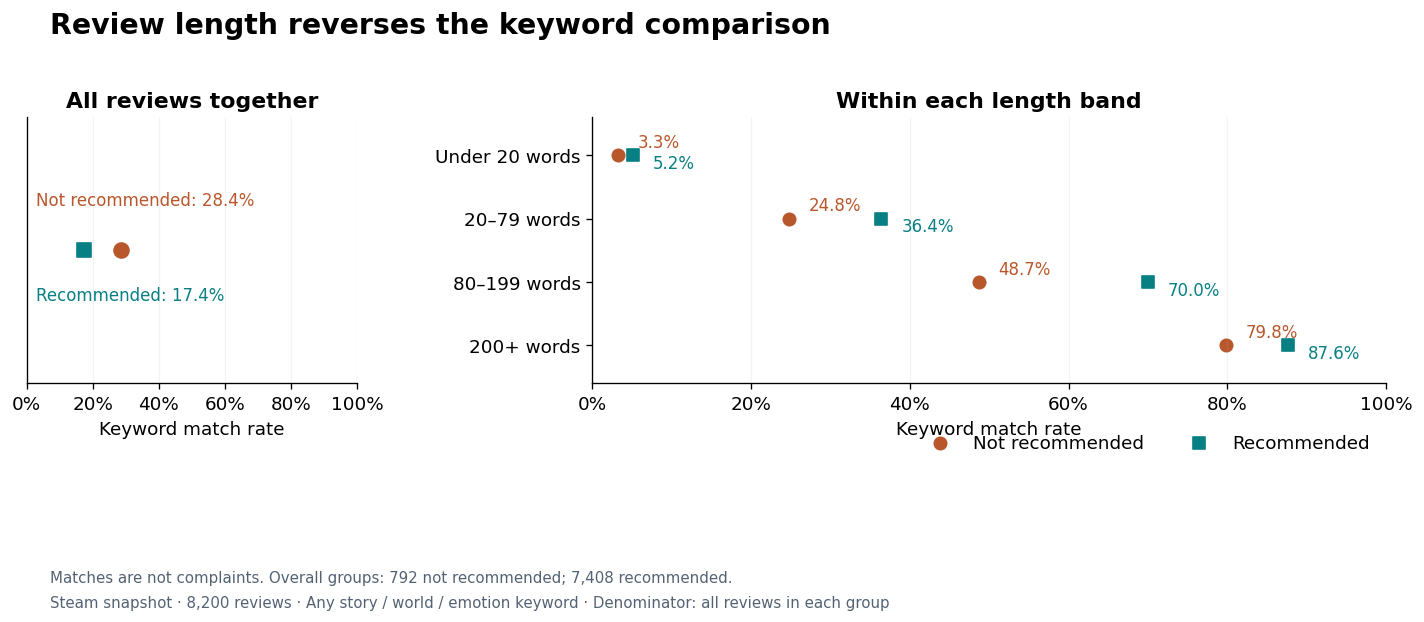

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={'width_ratios': [1, 2.4]})
fig.suptitle(
    'Review length reverses the keyword comparison',
    x=0.04, ha='left', fontsize=17, fontweight='bold',
)

# The same colors and 0–100% scale make the two panels directly comparable.
for group, marker in [('Not recommended', 'o'), ('Recommended', 's')]:
    axes[0].scatter(
        overall.loc[group, 'match_rate'], 0, color=COLORS[group], marker=marker, s=80,
    )
    axes[1].scatter(
        rates[group], np.arange(4), color=COLORS[group], marker=marker, label=group, s=55,
    )
    for row, value in enumerate(rates[group]):
        shift = -0.13 if group == 'Not recommended' else 0.20
        axes[1].text(
            value + 0.025, row + shift, f'{value:.1%}', color=COLORS[group], fontsize=10,
        )
axes[0].text(
    0.03, 0.24,
    f"Not recommended: {overall.loc['Not recommended', 'match_rate']:.1%}",
    color=COLORS['Not recommended'], fontsize=10,
)
axes[0].text(
    0.03, -0.26,
    f"Recommended: {overall.loc['Recommended', 'match_rate']:.1%}",
    color=COLORS['Recommended'], fontsize=10,
)
axes[0].set(title='All reviews together', yticks=[], ylim=(-0.7, 0.7))
axes[1].set(
    title='Within each length band', yticks=np.arange(4),
    yticklabels=rates.index, ylim=(3.6, -0.6),
)
for axis in axes:
    axis.set(xlim=(0, 1), xlabel='Keyword match rate')
    axis.xaxis.set_major_formatter(PercentFormatter(1))
    axis.grid(axis='x', alpha=0.15)
axes[1].legend(loc='lower right', bbox_to_anchor=(1, -0.32), ncol=2, frameon=False)
fig.text(
    0.04, 0.025,
    'Steam snapshot · 8,200 reviews · Any story / world / emotion keyword · '
    'Denominator: all reviews in each group',
    fontsize=9, color='#536273',
)
fig.text(
    0.04, 0.065,
    'Matches are not complaints. Overall groups: 792 not recommended; 7,408 recommended.',
    fontsize=9, color='#536273',
)
fig.tight_layout(rect=(0, 0.12, 1, 0.96), w_pad=2.8)
fig.savefig(FIGURES / 'length_reversal.png', dpi=160)
plt.show()

**Within all four length bands, recommending reviews have the higher keyword match rate.**
The aggregate pattern was sensitive to the groups' different length mixes.
This is an example of an aggregate comparison reversing after grouping the data.

We can make the effect easier to see by giving both recommendation groups the **same
mix of review lengths**: the distribution of all 8,200 reviews. This is a descriptive
reweighting, not a claim that length causes recommendation or explains every difference.

In [8]:
# For each group: multiply each band's rate by its share of the full dataset, then add.
common_mix = length_counts.sum(axis=1) / len(reviews)
standardized = rates.mul(common_mix, axis=0).sum(axis=0)
comparison = pd.DataFrame({'Original mix': overall.match_rate, 'Same length mix': standardized})
display(comparison.style.format('{:.1%}'))

,Original mix,Same length mix
recommendation,,
Not recommended,28.4%,14.0%
Recommended,17.4%,19.4%


With a common length mix, the rates are **14.0% for non-recommending reviews** and
**19.4% for recommending reviews**. Even this is still a comparison of keyword use,
not of story satisfaction. Broad length bands can contain other differences, and
templates can affect both length and matches.

**Practical consequence:** do not rank story problems by counting keyword matches in
negative reviews. Read the passages, separate praise from difficulty and confusion,
and report the denominator before proposing a product decision.

## 4. Return to the reviews: what should a research team investigate?

We read 24 additional keyword-matching reviews: 12 recommending and 12 not recommending,
selected deterministically outside the initial pilot. The assistant recorded whether
each review was relevant and how it discussed story, world, and emotion.

**These are assistant annotations, not independently validated human labels.** The
selected sample deliberately overrepresents non-recommending reviews and excludes
keyword misses. It supports discovery and specific examples, not prevalence estimates.
Short excerpts and source links are preserved in [the evidence table](../data/evidence.csv).

In [9]:
show_review(
    'H04',
    'The reviewer appreciates cinematics but reports missing context when a new chapter '
    'starts. A useful question is whether players understand where they are and why '
    'the story has moved there.',
)
show_review(
    'H23',
    'This recommending reviewer describes invisible boundaries interrupting immersion. '
    'We should investigate particular exploration moments, rather than assume the '
    'whole world design is disliked.',
)

**H04 · Not recommended** — [Original review](https://steamcommunity.com/profiles/76561198075924321/recommended/2358720/)

> the chapters just start at a different place with a different setting with no context whatsoever.

**Our reading:** The reviewer appreciates cinematics but reports missing context when a new chapter starts. A useful question is whether players understand where they are and why the story has moved there.

**H23 · Recommended** — [Original review](https://steamcommunity.com/profiles/76561198004117423/recommended/2358720/)

> I hated the amount of invisible walls; it was nauseating, and it broke the immersion.

**Our reading:** This recommending reviewer describes invisible boundaries interrupting immersion. We should investigate particular exploration moments, rather than assume the whole world design is disliked.

These comments suggest separate questions for narrative and level-design research.
They do not establish a confirmed bug, a widespread problem, or a requirement to
change the game's intended design.

The first two reviews also suggest studying **comprehension and enjoyment separately**.
A player can like the story without following every detail; a gameplay experience can
determine the recommendation even when the player praises the narrative.

| Evidence in this study | Question to investigate | A concrete next study |
|---|---|---|
| H04: chapter transitions feel unexplained | Do players understand the new place, objective, and narrative connection? | At selected transitions, ask playtesters to explain what changed and what they expect next. Record prior familiarity with Journey to the West. |
| H23: boundaries interrupt immersion | Which attempted routes create confusion or break immersion? | Observe navigation near selected boundaries. Record repeated attempts and player explanations before testing clearer cues. |
| H16 and H08: recommendation differs from story understanding or praise | How do story enjoyment, comprehension, and gameplay frustration combine? | Collect separate ratings and short explanations after key chapters; avoid one overall question standing in for all three. |

These are **proposed research steps**, not measured improvements. We would need new
observations to decide whether an intervention helps, who it helps, and what it costs.

## 5. What can we responsibly conclude?

**Wukong's overall recommendation is too coarse to describe its narrative experience.**
In selected reviews, admiration, confusion, frustration, and immersion coexist.
Across the full collection, even a simple keyword comparison changes direction when
review length is taken into account.

The project's contribution is a way to move from a broad score to **specific,
testable research questions**, with both quantitative context and traceable examples.
It does not identify the “biggest story problem” or estimate the revenue impact of a fix.

A useful next decision for a research team would be to investigate chapter transitions
and exploration boundaries, while measuring story comprehension separately from
enjoyment and overall recommendation. This is an agenda for investigation, not a
prioritized production roadmap.

**Scope to remember:** these are public English-tagged Steam reviews in one creation
window, observed in one snapshot. Non-reviewers, other languages, and later changes are
outside the study. Complaints do not prove churn, and edited reviews do not reconstruct
historical opinion. The numerical inputs can be rerun here; the full-text archive and
original raw pages are not included.

**Stop here if you came for the research story.** The appendix shows how we explored
vocabulary at scale and why we kept the text model out of the main conclusion.

## Appendix A. A vocabulary map, with visible limits

We also asked whether an unsupervised text model could help navigate longer reviews.
**TF-IDF** represents reviews as weighted words and two-word phrases. **NMF** looks for
a small set of vocabulary patterns that approximately reconstruct that matrix.
A pattern can mix praise and criticism; it is not automatically a complaint category.

The model uses **2,489 texts with enough retained vocabulary for this model**, out of
8,200 total reviews. It excludes very short text, some script mismatches, and texts
with fewer than five retained features. It fits one copy of each normalized text.
The script screen is not a validated English-language detector. The descriptive
analysis above continues to use all 8,200 IDs.

We publish the numeric TF-IDF matrix, vocabulary, row IDs, and settings so the model
can be refit without redistributing thousands of full review texts. Recreating the
matrix from raw text requires the original local archive. See
[the full methodology](../docs/methodology.md#exploratory-text-model) and the
[scikit-learn example](https://scikit-learn.org/1.7/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html).

In [10]:
from scipy.sparse import load_npz
from sklearn.decomposition import NMF
from threadpoolctl import threadpool_limits
from wukong_research.analysis import scale_adjusted_weights

matrix = load_npz(ROOT / 'data/model/tfidf.npz')
vocabulary = np.array(json.loads(
    (ROOT / 'data/model/vocabulary.json').read_text(encoding='utf-8')
))
model_rows = pd.read_csv(ROOT / 'data/model/review_ids.csv', dtype=str)
topic_names = json.loads((ROOT / 'data/model/topic_names.json').read_text(encoding='utf-8'))
metadata = json.loads((ROOT / 'data/model/metadata.json').read_text(encoding='utf-8'))
print(f'Model input: {matrix.shape[0]:,} texts × {matrix.shape[1]:,} vocabulary features.')

Model input: 2,489 texts × 7,651 vocabulary features.


In [11]:
# Eight groups are a readable exploration choice, not an optimized number of player needs.
model = NMF(n_components=8, init='random', random_state=42, max_iter=600, tol=0.0001)
with threadpool_limits(limits=2):
    weights = model.fit_transform(matrix)

# NMF component scales are arbitrary. Correct for that before choosing the largest weight.
shares = scale_adjusted_weights(weights, model.components_)
dominant = shares.argmax(axis=1)
topic_table = []
for index, component in enumerate(model.components_):
    topic_id = f'T{index + 1}'
    terms = ', '.join(vocabulary[component.argsort()[-8:][::-1]])
    topic_table.append({
        'Group': topic_id,
        'Working name': topic_names[topic_id]['label'],
        'Texts assigned': int((dominant == index).sum()),
        'Top terms': terms,
    })
topics = pd.DataFrame(topic_table).set_index('Group')
with pd.option_context('display.max_colwidth', None):
    display(topics)

,Working name,Texts assigned,Top terms
Group,,,
T1,"Combat, progression & friction",854,"bosses, time, chapter, don, attack, way, bad, dodge"
T2,Combat feel & mythic spectacle,316,"combat, feels, action, satisfying, world, mythology, stunning, visuals"
T3,Elden Ring comparisons,106,"elden, ring, elden ring, open world, ive, open, greatest, ring dark"
T4,General experience & value,431,"graphics, fun, story, gameplay, worth, hard, recommend, pc"
T5,Boss encounters,243,"boss, fights, boss fights, fight, boss fight, final, final boss, beat"
T6,Journey to the West & fandom,165,"journey, west, journey west, story, monkey, read, chinese, sun"
T7,Souls / God of War comparisons,176,"souls, god, god war, war, dark souls, dark, war souls, mix"
T8,Numeric rating language,198,"10, 10 10, 10 story, story 10, story, graphics 10, graphics, gameplay 10"


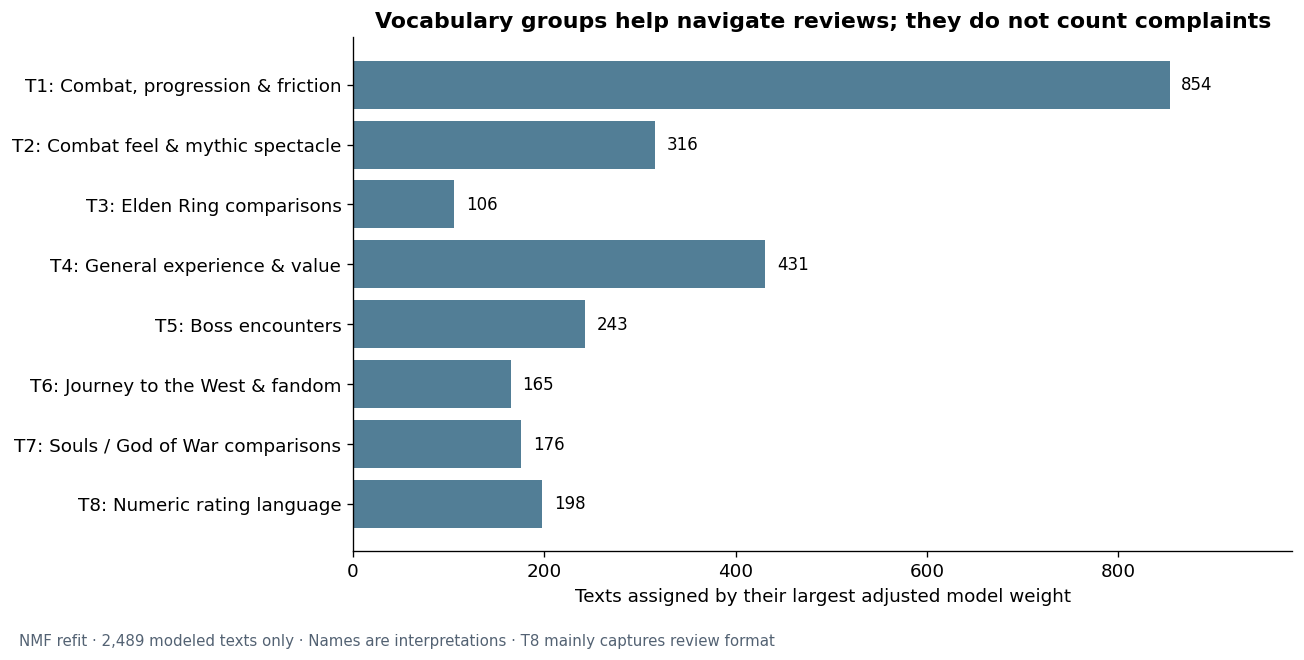

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))
labels = [f'{topic}: {name}' for topic, name in topics['Working name'].items()]
ax.barh(labels, topics['Texts assigned'], color='#527e96')
for row, count in enumerate(topics['Texts assigned']):
    ax.text(count + 12, row, str(count), va='center', fontsize=10)
ax.invert_yaxis()
ax.set(
    xlim=(0, topics['Texts assigned'].max() * 1.15),
    xlabel='Texts assigned by their largest adjusted model weight',
    title='Vocabulary groups help navigate reviews; they do not count complaints',
)
fig.text(
    0.02, 0.01,
    'NMF refit · 2,489 modeled texts only · Names are interpretations · '
    'T8 mainly captures review format',
    fontsize=9, color='#536273',
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIGURES / 'topic_map.png', dpi=160)
plt.show()

The map finds recognizable language around boss encounters, comparisons with other
games, and Journey to the West. It also finds **numeric rating language**—a writing
format, not a player need. A broad combat group mixes many different experiences.

Two checks prevent us from treating these names as established findings:

1. **How much of the input does the small model leave unexplained?** We compare its
   reconstruction error with the size of the original matrix. Lower is closer, but
   this is not a semantic accuracy score.
2. **Do different starting points find similar groups?** We refit with other random
   seeds and match components by vocabulary similarity. Similarity of 1 means the
   same direction in vocabulary space; near 0 means very little overlap.

Primary model: 123 iterations; relative reconstruction error = 0.9748.


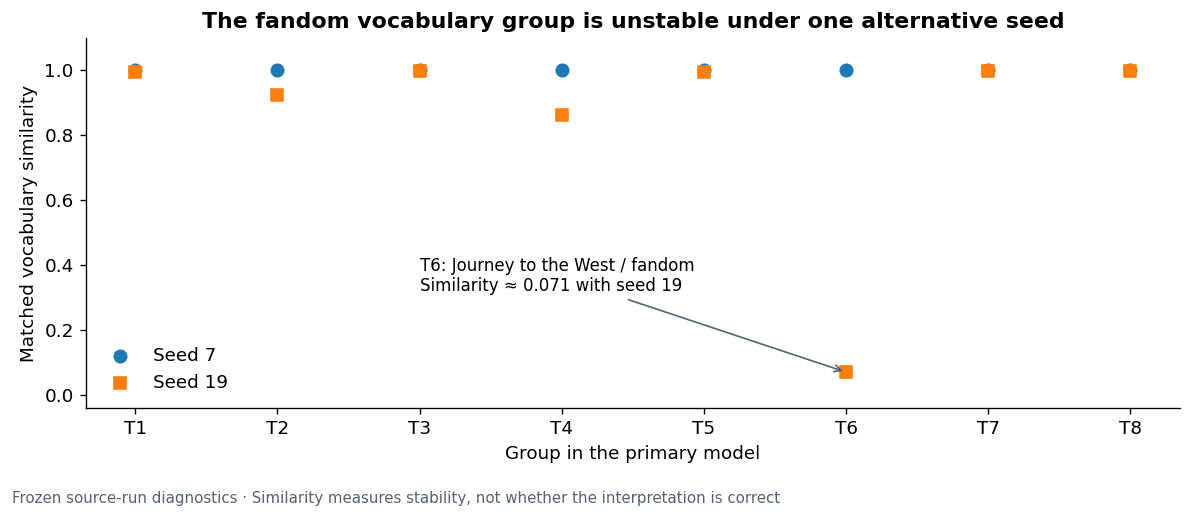

In [13]:
relative_error = model.reconstruction_err_ / np.linalg.norm(matrix.data)
print(
    f'Primary model: {model.n_iter_} iterations; '
    f'relative reconstruction error = {relative_error:.4f}.'
)

# These are frozen diagnostics from the original saved run, not newly computed seed checks.
# Refit every comparison with: python scripts/check_model_stability.py
stability = pd.DataFrame([
    {'Topic': topic['topic_id'], 'Seed': run['seed'], 'Similarity': topic['cosine']}
    for run in metadata['stability'] for topic in run['matched_topics']
])
stability_plot = stability.pivot(index='Topic', columns='Seed', values='Similarity')
fig, ax = plt.subplots(figsize=(10, 4.3))
for seed, marker in [(7, 'o'), (19, 's')]:
    ax.scatter(
        stability_plot.index, stability_plot[seed],
        marker=marker, label=f'Seed {seed}', s=55,
    )
ax.set(
    ylim=(-0.04, 1.1), ylabel='Matched vocabulary similarity',
    xlabel='Group in the primary model',
    title='The fandom vocabulary group is unstable under one alternative seed',
)
ax.annotate(
    'T6: Journey to the West / fandom\nSimilarity ≈ 0.071 with seed 19',
    xy=(5, 0.071), xytext=(2, 0.32),
    arrowprops={'arrowstyle': '->', 'color': '#536273'}, fontsize=10,
)
ax.legend(frameon=False, loc='lower left')
fig.text(
    0.01, 0.01,
    'Frozen source-run diagnostics · Similarity measures stability, '
    'not whether the interpretation is correct',
    fontsize=9, color='#536273',
)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(FIGURES / 'topic_stability.png', dpi=160)
plt.show()

The primary reconstruction residual is about **0.975**: much vocabulary variation
remains outside this small map. Seed 7 reproduces the main assignments closely, but
seed 19 produces different assignments (adjusted Rand index about **0.714**) and a
poorly matched fandom group. Six, eight, and ten groups have residuals of about
**0.978, 0.975, and 0.972**; more groups do not resolve the interpretation problem.

**How we use the model:** to find vocabulary patterns worth reading. We do not use its
assignments as validated sentiment, complaint counts, or evidence that a particular
theme matters to a fixed share of players. The main findings above stand on direct
calculations and explicit review examples.

## Appendix B. Reproduction and accountability

This notebook executes offline from the public prepared inputs. Running
`python scripts/run_notebook.py` rebuilds this notebook, its HTML companion, and figures.
`python -m unittest discover -s tests -v` checks the data and calculations;
`python scripts/check_model_stability.py` repeats the optional model comparisons.

- [Data dictionary](../docs/data_dictionary.md): each input, field, and denominator.
- [Methodology](../docs/methodology.md): collection, keyword rules, cleaning, sampling, and model choices.
- [Research brief](../docs/research_brief.md): findings and proposed next studies.
- [Provenance](../data/provenance.json): collection window, API parameters, reconciliation, and source hashes.

**AI assistance:** code, analysis, prose, and annotations were developed with AI assistance.
The review labels are assistant judgments. There is no claim of independent human
validation. Short review quotations remain attributable to their original authors;
this project is independent of Valve and the game's developer.

**The question to carry forward:** what does a player understand, enjoy, and feel at
a specific moment—and how is that different from whether they recommend the game?